In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [139]:
import pyarrow.parquet as pq
trips = pq.read_table('Dataset/Trip Data Ordered by Month/yellow_tripdata_2026-01.parquet')
trips = trips.to_pandas()

In [140]:
trips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3724889 entries, 0 to 3724888
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

<h2>Feature Engineering</h2>

<ol>
  <li>
    <strong>Datetime features</strong> (from <code>tpep_pickup_datetime</code> / <code>tpep_dropoff_datetime</code>)
    <ul>
      <li><code>trip_duration = dropoff − pickup</code> (minutes) — strong predictor</li>
      <li><code>pickup_hour</code>, <code>pickup_dayofweek</code>, <code>pickup_month</code></li>
      <li><code>is_weekend</code> (binary)</li>
      <li><code>is_rush_hour</code> (e.g., 7–10am, 4–7pm on weekdays)</li>
      <li><code>is_late_night</code> (e.g., 11pm–5am, often has night surcharge)</li>
      <li><code>is_holiday</code> (map against NYC holiday calendar)</li>
      <li><code>speed_mph = trip_distance / (trip_duration / 60)</code> — useful for outlier detection, not necessarily as a model input (can leak/circular with fare)</li>
    </ul>
  </li>

  <li>
    <strong>Location features</strong> (<code>PULocationID</code>, <code>DOLocationID</code>)
    <ul>
      <li><code>is_airport_pickup</code> / <code>is_airport_dropoff</code> (flag JFK/LGA zone IDs)</li>
      <li><code>pickup_borough</code>, <code>dropoff_borough</code> (join TLC Taxi Zone lookup table for zone &rarr; borough mapping)</li>
      <li><code>same_zone_trip</code> (<code>PU == DO</code>, binary)</li>
      <li><code>route_pair</code> = combination of <code>PULocationID</code> + <code>DOLocationID</code> (high-cardinality we can ignore it)</li>
      <li><code>zone_popularity</code> = frequency count of each <code>PULocationID</code>/<code>DOLocationID</code> in training data</li>
    </ul>
  </li>

  <li>
    <strong>Trip characteristics</strong>
    <ul>
      <li><code>trip_distance</code></li>
    </ul>
  </li>

  <li>
    <strong>Categorical encodings</strong>
    <ul>
      <li><code>RatecodeID</code> &rarr; one-hot (JFK/Newark/negotiated fares behave very differently — important signal)</li>
    </ul>
  </li>

  <li>
    <strong>Surcharge/fee flags</strong> (rather than raw amounts, since these cause fare, not predict it)
    <p>
       <code>extra</code>, <code>mta_tax</code>, <code>tip_amount</code>, <code>tolls_amount</code>, <code>improvement_surcharge</code>, <code>congestion_surcharge</code>, <code>airport_fee</code>, <code>cbd_congestion_fee</code> are components that sum into <code>total_amount</code>. Using them to predict <code>fare_amount</code> or <code>total_amount</code> is target leakage if they're mechanically derived from the same trip. Better approach:
    </p>
    <ul>
      <li><strong>If predicting <code>total_amount</code>:</strong> you could legitimately include structural flags like <code>has_congestion_surcharge</code>, <code>has_airport_fee</code>, <code>has_cbd_fee</code> (binary indicators of applicability) rather than the dollar amounts themselves.</li>
      <li><strong>If predicting <code>fare_amount</code> (the meter fare only):</strong> exclude tolls, tips, surcharges entirely — they're not causally upstream of the meter fare, they're separate line items.</li>
    </ul>
  </li>

  <li>
    <strong>Derived interaction features</strong>
    <ul>
      <li><code>distance &times; rate_code</code> (JFK flat rate vs standard metered differ structurally)</li>
      <li><code>duration &times; hour</code> (traffic-driven time cost varies by time of day)</li>
    </ul>
  </li>
</ol>

<h3>Key modeling notes</h3>
<ul>
  <li>Filter out data errors: negative/zero distance or duration, dropoff before pickup, <code>passenger_count = 0</code>, unrealistic speeds (&gt;80mph sustained).</li>
  <li><code>RatecodeID</code> is probably your single highest-value categorical feature — flat-rate airport trips have a completely different fare structure than metered trips.</li>
  <li>log-transforming <code>fare_amount</code> and <code>trip_distance</code> (right-skewed distributions).</li>
</ul>

In [141]:
trips['duration'] = (
    trips['tpep_dropoff_datetime'] - trips['tpep_pickup_datetime']
).dt.total_seconds() / 60

trips['pick_up_hour'] = trips['tpep_pickup_datetime'].dt.hour
trips['day_of_the_week'] = trips['tpep_pickup_datetime'].dt.weekday  # Monday=0, Sunday=6
trips['pick_up_month'] = trips['tpep_pickup_datetime'].dt.month

trips['is_weekend'] = trips['day_of_the_week'].isin([5, 6]).astype(int) #to check saturday or sunday

is_weekday = trips['day_of_the_week'] < 5
morning_rush = trips['pick_up_hour'].between(7, 9)    # 7am to 10am
evening_rush = trips['pick_up_hour'].between(16, 18)  # 4pm to 7pm

trips['is_rush_hour'] = (is_weekday & (morning_rush | evening_rush)).astype(int)

trips['is_late_night'] = (
    (trips['pick_up_hour'] >= 23) | (trips['pick_up_hour'] < 5)
).astype(int)

In [142]:
trips.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,congestion_surcharge,Airport_fee,cbd_congestion_fee,duration,pick_up_hour,day_of_the_week,pick_up_month,is_weekend,is_rush_hour,is_late_night
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,...,2.5,0.0,0.00,5.550000,0,3,1,0,0,1
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,...,2.5,0.0,0.75,5.716667,0,3,1,0,0,1
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,...,2.5,0.0,0.75,8.883333,0,3,1,0,0,1
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,...,2.5,0.0,0.75,42.800000,0,3,1,0,0,1
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,...,2.5,0.0,0.75,13.500000,0,3,1,0,0,1


In [143]:
Zones_df = pd.read_csv('Dataset/Zones Lookup.csv')
zone_to_borough = Zones_df.set_index('LocationID')['Borough']


trips['boroughPickUpPoint'] = trips['PULocationID'].map(zone_to_borough)
trips['boroughDropOffPoint'] = trips['DOLocationID'].map(zone_to_borough)


In [144]:
trips.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,cbd_congestion_fee,duration,pick_up_hour,day_of_the_week,pick_up_month,is_weekend,is_rush_hour,is_late_night,boroughPickUpPoint,boroughDropOffPoint
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,...,0.00,5.550000,0,3,1,0,0,1,Manhattan,Manhattan
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,...,0.75,5.716667,0,3,1,0,0,1,Manhattan,Manhattan
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,...,0.75,8.883333,0,3,1,0,0,1,Manhattan,Manhattan
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,...,0.75,42.800000,0,3,1,0,0,1,Manhattan,Manhattan
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,...,0.75,13.500000,0,3,1,0,0,1,Manhattan,Manhattan


In [145]:
trips['is_airport_pickup'] = np.where((trips['PULocationID']==132) | (trips['PULocationID'] == 138)| (trips['PULocationID'] == 1) , 1,0)
trips['is_airport_dropoff'] = np.where((trips['DOLocationID']==132) | (trips['DOLocationID'] == 138)| (trips['DOLocationID'] == 1) , 1,0)

trips['RatecodeID'] = np.where(
    ((trips['PULocationID'] == 132) & (trips['boroughDropOffPoint'] == 'Manhattan')) |
    ((trips['DOLocationID'] == 132) & (trips['boroughPickUpPoint'] == 'Manhattan')),
    2,
    trips['RatecodeID']
)



In [146]:
trips['SameZone'] = np.where((trips['PULocationID'] == trips['DOLocationID']) , 1 , 0)

<h3>Droping All Fixed Taxs , tolls and tips</h3>

In [147]:
corr = trips.corr(numeric_only = True)

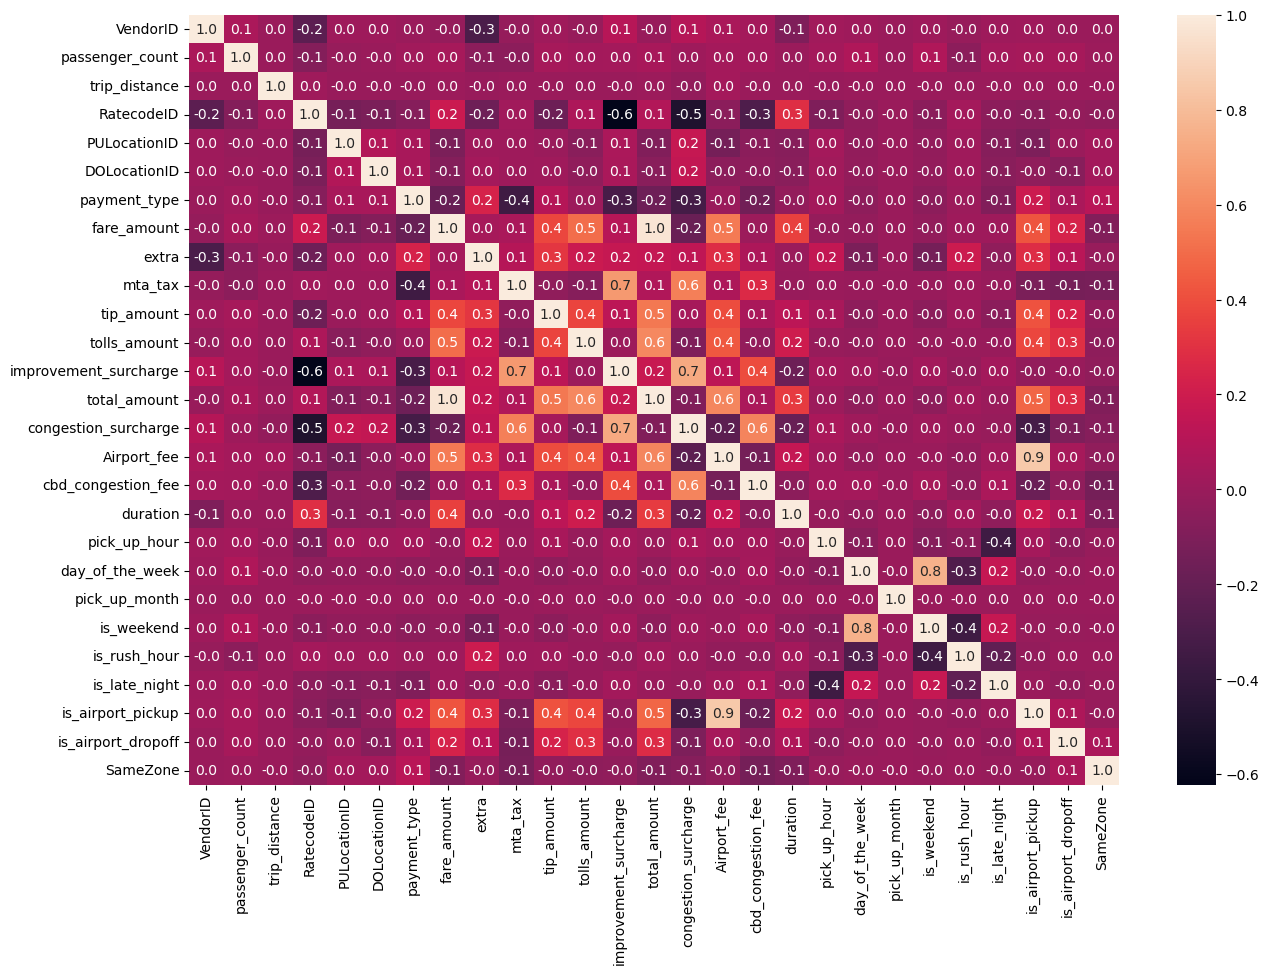

In [148]:
plt.figure(figsize=(15, 10))
sns.heatmap(corr ,cmap="rocket" , annot=True , fmt='.1f')
plt.show()

<h3>Since we are trying to predict the Net Fare price of the trip only not the total price i'll drop all the taxes columns</h3>

In [149]:
trips = trips.drop(columns = ['extra' , 'mta_tax' , 'tip_amount' , 'tolls_amount' , 'improvement_surcharge' , 'congestion_surcharge', 'Airport_fee' , 'cbd_congestion_fee' , 'total_amount'])

In [150]:
trips = trips.drop(columns=['tpep_pickup_datetime' , 'tpep_dropoff_datetime'])

In [151]:
trips = trips.drop(columns=['payment_type' , 'passenger_count'])

In [152]:
trips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3724889 entries, 0 to 3724888
Data columns (total 19 columns):
 #   Column               Dtype  
---  ------               -----  
 0   VendorID             int32  
 1   trip_distance        float64
 2   RatecodeID           float64
 3   store_and_fwd_flag   object 
 4   PULocationID         int32  
 5   DOLocationID         int32  
 6   fare_amount          float64
 7   duration             float64
 8   pick_up_hour         int32  
 9   day_of_the_week      int32  
 10  pick_up_month        int32  
 11  is_weekend           int64  
 12  is_rush_hour         int64  
 13  is_late_night        int64  
 14  boroughPickUpPoint   object 
 15  boroughDropOffPoint  object 
 16  is_airport_pickup    int64  
 17  is_airport_dropoff   int64  
 18  SameZone             int64  
dtypes: float64(4), int32(6), int64(6), object(3)
memory usage: 454.7+ MB


In [153]:
trips.to_parquet('Trips_phase1.parquet')